In [57]:
# EDA
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# Text Preprocessing
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer
# Model Building and classification
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
# To keep notebook clean
import warnings
warnings.filterwarnings("ignore")

In [16]:
df = pd.read_csv("/content/train .csv")
df.sample(3)

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
30762,51b36f17517b42f8,Thanks you very much this just what I wanted I...,0,0,0,0,0,0
108751,45742129db760432,I also wanted to added that when something is ...,0,0,0,0,0,0
54186,90c7746697c68a9e,would mislead most reasonable people,0,0,0,0,0,0


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB


In [18]:
df.isnull().sum()

,0
id,0
comment_text,0
toxic,0
severe_toxic,0
obscene,0
threat,0
insult,0
identity_hate,0


In [19]:
df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [20]:
df.columns

Index(['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat',
       'insult', 'identity_hate'],
      dtype='object')

In [21]:
df[df[input()]==1]["comment_text"].iloc[0]

toxic


'COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK'

In [22]:
x = df.iloc[:,2:].sum()
x

,0
toxic,15294
severe_toxic,1595
obscene,8449
threat,478
insult,7877
identity_hate,1405


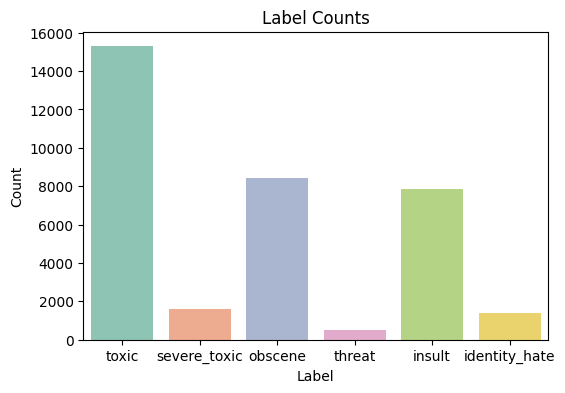

In [23]:
plt.figure(figsize=(6,4))
sns.barplot(x = x.index,y = x.values,alpha=0.8,palette="Set2")
plt.title("Label Counts")
plt.ylabel("Count")
plt.xlabel("Label")
plt.show()

In [55]:
### Data Preprocessing

In [25]:
df.drop(columns="id",inplace=True)

In [26]:
df


,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0
...,...,...,...,...,...,...,...
159566,""":::::And for the second time of asking, when ...",0,0,0,0,0,0
159567,You should be ashamed of yourself \n\nThat is ...,0,0,0,0,0,0
159568,"Spitzer \n\nUmm, theres no actual article for ...",0,0,0,0,0,0
159569,And it looks like it was actually you who put ...,0,0,0,0,0,0


In [54]:
### Removing Stopwords

In [31]:
stopwords = set(stopwords.words("english"))
def remove_stopwords(text):
    no_stop_words_text = [w for w in text.split() if not w in stopwords]
    return " ".join(no_stop_words_text)

In [32]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"what's", "what is ", text)
    text = re.sub(r"\'s", " ", text)
    text = re.sub(r"\'ve", " have ", text)
    text = re.sub(r"can't", "can not ", text)
    text = re.sub(r"n't", " not ", text)
    text = re.sub(r"i'm", "i am ", text)
    text = re.sub(r"\'re", " are ", text)
    text = re.sub(r"\'d", " would ", text)
    text = re.sub(r"\'ll", " will ", text)
    text = re.sub(r"\'scuse", " excuse ", text)
    text = re.sub('\W', ' ', text)
    text = re.sub('\s+', ' ', text)
    text = text.strip(' ')
    return text

In [33]:
stemmer = SnowballStemmer("english")

def stemming(sentence):
    stemmed_sentence = ""
    for word in sentence.split():
        stemmed_word = stemmer.stem(word)
        stemmed_sentence += stemmed_word+" "
    stemmed_sentence = stemmed_sentence.strip()
    return stemmed_sentence

In [34]:
df["comment_text"] =df["comment_text"].apply(lambda x: remove_stopwords(x))

In [35]:
df["comment_text"] =df["comment_text"].apply(lambda x: clean_text(x))

In [36]:
df["comment_text"] =df["comment_text"].apply(lambda x: stemming(x))

In [46]:
X = df["comment_text"]
y = df.drop(columns=["comment_text"],axis=1)

In [47]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [48]:
def run_pipeline(pipeline,X_train,X_test,y_train,y_test):
    # Traning the model
    pipeline.fit(X_train,y_train)
    # prediction from model
    predictions = pipeline.predict(X_test)
    pred_probs = pipeline.predict_proba(X_test)
    # Accuracy
    print("Accuracy:",accuracy_score(y_test,predictions))

In [49]:
from sklearn.multiclass import OneVsRestClassifier
LR_pipeline = Pipeline([
    ('tfidf',TfidfVectorizer(stop_words='english')),
    ('LR_model',OneVsRestClassifier(LogisticRegression(),n_jobs=1))
])

In [50]:
run_pipeline(LR_pipeline,X_train,X_test,y_train,y_test)

Accuracy: 0.9180322732257559


In [53]:
### Now we will make prediction on unseen comment

In [51]:
labels = y_train.columns.values

In [52]:
sentence = input("Your Comment : ")
print("X"*40)
stemmed_sentence = stemming(sentence)
results = LR_pipeline.predict([stemmed_sentence])[0]
for label,result in zip(labels,results):
    print(label,"-------",result)

Your Comment : who are you
XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
toxic ------- 0
severe_toxic ------- 0
obscene ------- 0
threat ------- 0
insult ------- 0
identity_hate ------- 0
